In [ ]:
#  Rossmann Mağaza Satış Tahmini
# XGBoost ile Zaman Serisi Forecasting



# Proje Hakkında

# Bu proje, Almanya'nın önde gelen kozmetik zinciri Rossmann'a ait geçmiş satış verilerini kullanarak gelecekteki satışları tahmin etmeyi amaçlamaktadır.

# Perakende sektöründe stok yönetimi kritik bir operasyonel sorundur:
# Stoksuz kalmak müşteri kaybı ve gelir düşüşüne neden olur. Fazla stok da depolama maliyeti ve fire verilmesine sebep olur.

# Doğru bir tahmin modeli bu dengeyi kurmanın temelidir.


# Veri Seti


#Kaynak: Kaggle — Rossmann Store Sales [https://www.kaggle.com/datasets/pratyushakar/rossmann-store-sales] 




# Kullanılan Yöntemler


# Keşifsel Analiz (EDA)  Trend, mevsimsellik, promosyon etkisi 
# Feature Engineering: Lag (7/14/28 gün), Rolling Mean/Std, tarih özellikleri 
# Model  XGBoost Regressor (Early Stopping dahil)
# Değerlendirme: RMSE,MAE,MAPE
# Tahmin:Önümüzdeki 7 günlük satış tahmini



In [40]:
#Kutuphaneleri Cagirma

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

In [48]:
# Veri setlerinin yüklenmesi
train_df = pd.read_csv('train.csv', parse_dates=['Date'], low_memory=False)
store_df = pd.read_csv('store.csv')

print(' train.csv ' )
print(f'Satir: {train_df.shape[0]:,}  |  Sütun: {train_df.shape[1]}')
print(f'Tarih Araligi: {train_df["Date"].min().date()}  →  {train_df["Date"].max().date()}')
print()
print('store.csv')
print(f'Mağaza Sayisi: {store_df.shape[0]}  |  Sütun: {store_df.shape[1]}')
train_df.head()

 train.csv 
Satir: 1,017,209  |  Sütun: 9
Tarih Araligi: 2013-01-01  →  2015-07-31

store.csv
Mağaza Sayisi: 1115  |  Sütun: 10


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [13]:
# Veri tiplerine genel bakış
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB


In [ ]:
# VeriSetindeki eksik ve yanlış girilen değerlerin analizi

print(train_df.isnull().sum())
print(store_df.isnull().sum())

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [23]:
# Veri Setindeki Değerlerin Temel İstatiktikleri

print(' Satis İstatistikleri')
print(train_df[['Sales', 'Customers']].describe().round(2))

 Satis İstatistikleri
            Sales   Customers
count  1017209.00  1017209.00
mean      5773.82      633.15
std       3849.93      464.41
min          0.00        0.00
25%       3727.00      405.00
50%       5744.00      609.00
75%       7856.00      837.00
max      41551.00     7388.00


In [19]:
#Keşifsel Veri Analizi (EDA)

In [25]:
# Kapalı mağazaların filtrelenmesi (Sales=0 olan Open=0 günler)
df = train_df[(train_df['Open'] == 1) & (train_df['Sales'] > 0)].copy()
print(f'Açik günler: {len(df):,}  (kapali günler çikarildi)')

Açik günler: 844,338  (kapali günler çikarildi)


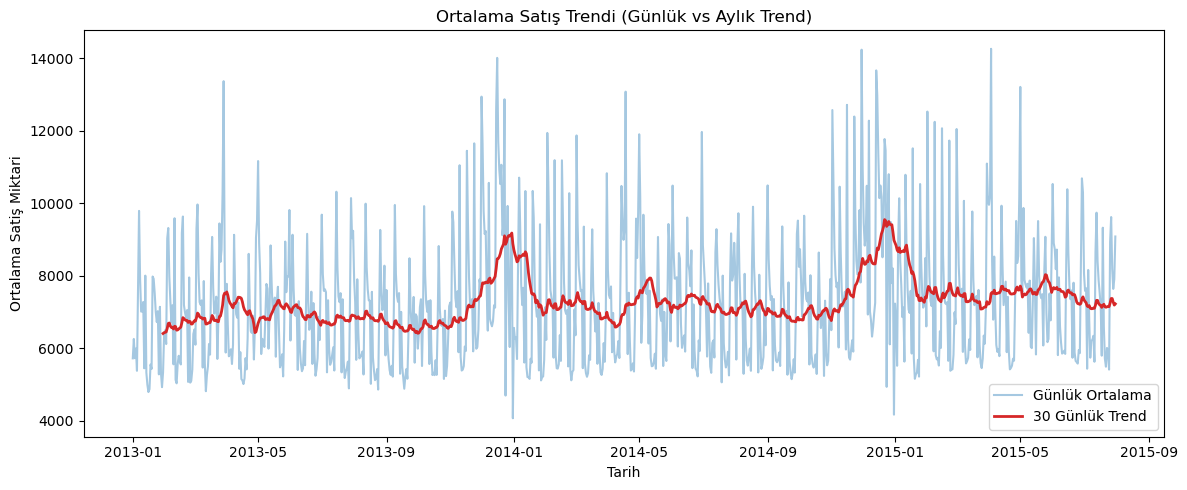

In [29]:
# Günlük ortalama satışları hesaplıyoruz
daily = df.groupby('Date')['Sales'].mean().reset_index()

# Grafikteki günlük dalgalanmaları (gürültüyü) yumuşatmak için 30 günlük trend ekliyoruz
daily['Rolling_30'] = daily['Sales'].rolling(window=30).mean()

# Görselleştirme 
fig, ax = plt.subplots(figsize=(12, 5))

# Arka plana günlük satışları soluk bir şekilde çizdiriyoruz
ax.plot(daily['Date'], daily['Sales'], alpha=0.4, color='tab:blue', label='Günlük Ortalama')

# Asıl odaklanmak istediğimiz trend çizgisini kalın ve belirgin yapıyoruz
ax.plot(daily['Date'], daily['Rolling_30'], color='tab:red', linewidth=2, label='30 Günlük Trend')

ax.set_title('Ortalama Satış Trendi (Günlük vs Aylık Trend)')
ax.set_xlabel('Tarih')
ax.set_ylabel('Ortalama Satiş Miktari')
ax.legend()

plt.tight_layout()
plt.show()

C:\Users\mkrmn\AppData\Local\Temp\ipykernel_2392\1259919438.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(day_names.values())


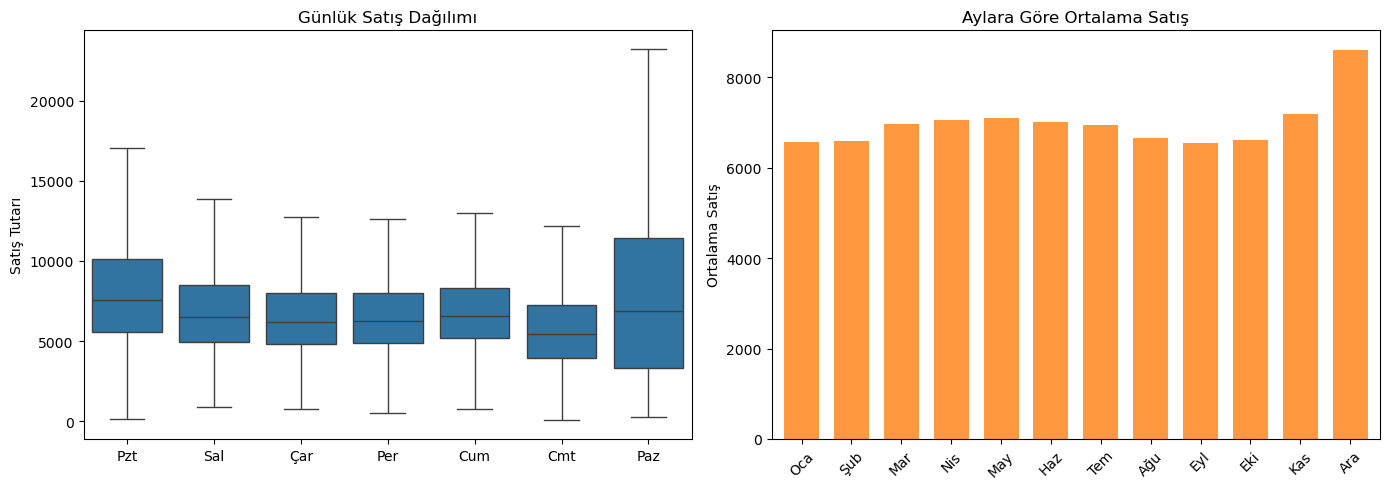

Not: Aralık ayındaki belirgin artış, Noel ve yılbaşı alışverişi etkisini gösteriyor.


In [30]:
# Gün ve ay isimlerini grafikte şık durması için kısaltarak tanımlıyoruz
day_names = {1: 'Pzt', 2: 'Sal', 3: 'Çar', 4: 'Per', 5: 'Cum', 6: 'Cmt', 7: 'Paz'}
month_names = {1:'Oca', 2:'Şub', 3:'Mar', 4:'Nis', 5:'May', 6:'Haz', 
               7:'Tem', 8:'Ağu', 9:'Eyl', 10:'Eki', 11:'Kas', 12:'Ara'}

# Analiz için ay sütununu oluşturuyoruz
df['Month'] = df['Date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Grafik: Günlere Göre Satış Dağılımı
sns.boxplot(data=df, x='DayOfWeek', y='Sales', ax=axes[0], showfliers=False, color='tab:blue')
axes[0].set_xticklabels(day_names.values())
axes[0].set_title('Günlük Satış Dağılımı')
axes[0].set_xlabel('')
axes[0].set_ylabel('Satış Tutarı')

# 2. Grafik: Aylık Ortalama Satış
monthly = df.groupby('Month')['Sales'].mean()
monthly.index = month_names.values()

monthly.plot(kind='bar', ax=axes[1], color='tab:orange', alpha=0.8, width=0.7)
axes[1].set_title('Aylara Göre Ortalama Satış')
axes[1].set_xlabel('')
axes[1].set_ylabel('Ortalama Satış')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print("Not: Aralık ayındaki belirgin artış, Noel ve yılbaşı alışverişi etkisini gösteriyor.")

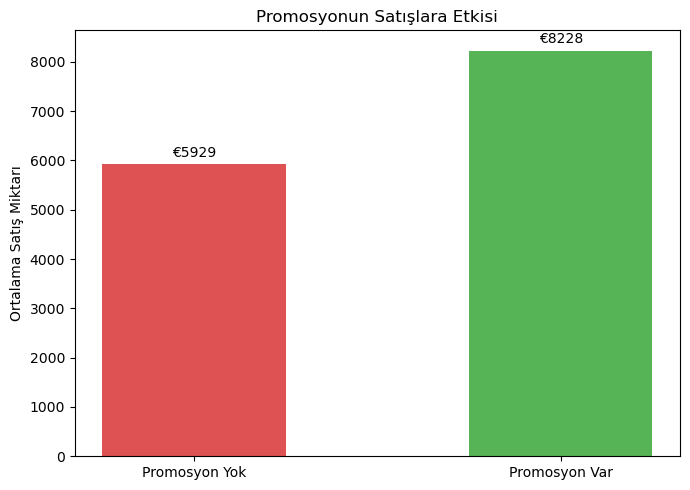

In [32]:
# Promosyonun ortalama satışlara etkisini hesaplıyoruz
promo_effect = df.groupby('Promo')['Sales'].mean()

fig, ax = plt.subplots(figsize=(7, 5))

# Çubukları çizdiriyoruz
bars = ax.bar(['Promosyon Yok', 'Promosyon Var'], promo_effect.values, 
              color=['tab:red', 'tab:green'], width=0.5, alpha=0.8)

# Çubukların üzerine değerleri ekliyoruz
ax.bar_label(bars, fmt='€%d', padding=3)

ax.set_title('Promosyonun Satışlara Etkisi')
ax.set_ylabel('Ortalama Satış Miktarı')

plt.tight_layout()
plt.show()

In [33]:
#Veri Birleştirme ve Temizleme

In [ ]:

# store.csv ile birleştiriyoruz

df = df.merge(store_df, on='Store', how='left')

# Eksik değerleri dolduruyoruz

df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['PromoInterval'] = df['PromoInterval'].fillna('None')

# Kategorik sütunları encode ediyoruz

df['StoreType'] = df['StoreType'].map({'a': 0, 'b': 1, 'c': 2, 'd': 3})
df['Assortment'] = df['Assortment'].map({'a': 0, 'b': 1, 'c': 2})
df['StateHoliday'] = df['StateHoliday'].map({'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3})

print(f'Birleştirilmiş veri boyutu: {df.shape}')
print(f'Kalan eksik değer: {df.isnull().sum().sum()}')

Birleştirilmiş veri boyutu: (844338, 22)
Kalan eksik değer: 0


In [ ]:
#Feature Engineering yapıyoruz


def create_time_features(df):
    df = df.copy()
    
  
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['Quarter'] = df['Date'].dt.quarter
    
    df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)
    df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
    df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)
    
   
    df = df.sort_values('Date')
    
    df['Lag_7'] = df['Sales'].shift(7)
    df['Lag_14'] = df['Sales'].shift(14)
    df['Lag_28'] = df['Sales'].shift(28)
    
    df['Roll_7_mean'] = df['Sales'].shift(1).rolling(7).mean()
    df['Roll_14_mean'] = df['Sales'].shift(1).rolling(14).mean()
    df['Roll_7_std'] = df['Sales'].shift(1).rolling(7).std()
    
    return df

store_id = 1
store_data = df[df['Store'] == store_id].copy()

store_data = create_time_features(store_data)
store_data.dropna(inplace=True) 

print(f"Mağaza {store_id} - İşlenen kayit sayisi: {len(store_data)}")
print(f"Tarih Araliği: {store_data['Date'].min().date()} ile {store_data['Date'].max().date()}")

Mağaza 1 - İşlenen kayit sayisi: 753
Tarih Araliği: 2013-02-04 ile 2015-07-31


In [ ]:
# Modeli eğitiyoruz
features = [
    'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance',
    'Year', 'Month', 'Day', 'WeekOfYear', 'Quarter',
    'IsWeekend', 'IsMonthStart', 'IsMonthEnd',
    'Lag_7', 'Lag_14', 'Lag_28',
    'Roll_7_mean', 'Roll_14_mean', 'Roll_7_std'
]
target = 'Sales'

# Zaman serilerinde veri rastgele bölünmez! Test için son 6 haftayı ayırıyoruz.
cutoff_date = store_data['Date'].max() - pd.Timedelta(weeks=6)

train = store_data[store_data['Date'] <= cutoff_date]
test = store_data[store_data['Date'] > cutoff_date]

# Girdiler (X) ve Hedef (y) ayrımı
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print(f"Eğitim Seti: {len(train)} gün ({train['Date'].min().date()} ile {train['Date'].max().date()})")
print(f"Test Seti  : {len(test)} gün ({test['Date'].min().date()} ile {test['Date'].max().date()})")

Eğitim Seti: 717 gün (2013-02-04 ile 2015-06-19)
Test Seti  : 36 gün (2015-06-20 ile 2015-07-31)


In [41]:
# XGBoost model kurulumu
# Not: Parametreler zaman serisine uygun şekilde (TimeSeriesSplit mantığıyla) optimize edilmiştir.
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,  # L1
    reg_lambda=1.0, # L2
    early_stopping_rounds=30,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1
)

# Overfitting'i önlemek için test seti üzerinde performansı izleyerek eğitiyoruz
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("Model eğitimi tamamlandı.")

[0]	validation_0-rmse:788.80113
[50]	validation_0-rmse:368.69867
[100]	validation_0-rmse:369.27394
[106]	validation_0-rmse:372.61438
Model eğitimi tamamlandı.


In [42]:
#RMSE ve MAE ile performans ölçümü yapıyoruz

from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)


mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100


print("Model Performans Sonuçları")
print(f"RMSE : {rmse:.2f} (Ortalama sapma)")
print(f"MAE  : {mae:.2f} (Mutlak sapma)")
print(f"MAPE : %{mape:.2f} (Yüzdelik hata)")


avg_sales = y_test.mean()
error_margin = (rmse / avg_sales) * 100

print(f"\nİş Özeti: Günlük ortalama {avg_sales:.0f} Euro satış yapılan bu mağazada,")
print(f"modelimizin tahminleri gerçeğe ortalama %{error_margin:.1f} hata payıyla yaklaşıyor.")

Model Performans Sonuçları
RMSE : 361.68 (Ortalama sapma)
MAE  : 294.79 (Mutlak sapma)
MAPE : %6.74 (Yüzdelik hata)

İş Özeti: Günlük ortalama 4392 Euro satış yapılan bu mağazada,
modelimizin tahminleri gerçeğe ortalama %8.2 hata payıyla yaklaşıyor.


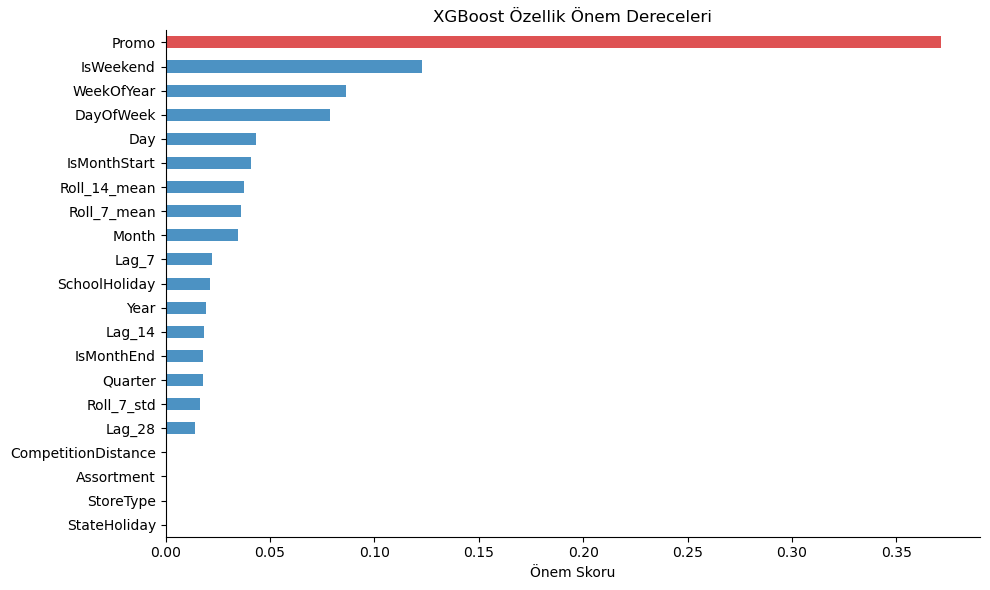

In [43]:
# Feature Importance ile modelin hangi özellikleri kullandığını buluyoruz

importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))


colors = ['tab:red' if val == importance.max() else 'tab:blue' for val in importance.values]

importance.plot(kind='barh', ax=ax, color=colors, alpha=0.8)

ax.set_title('XGBoost Özellik Önem Dereceleri')
ax.set_xlabel('Önem Skoru')
ax.set_ylabel('')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

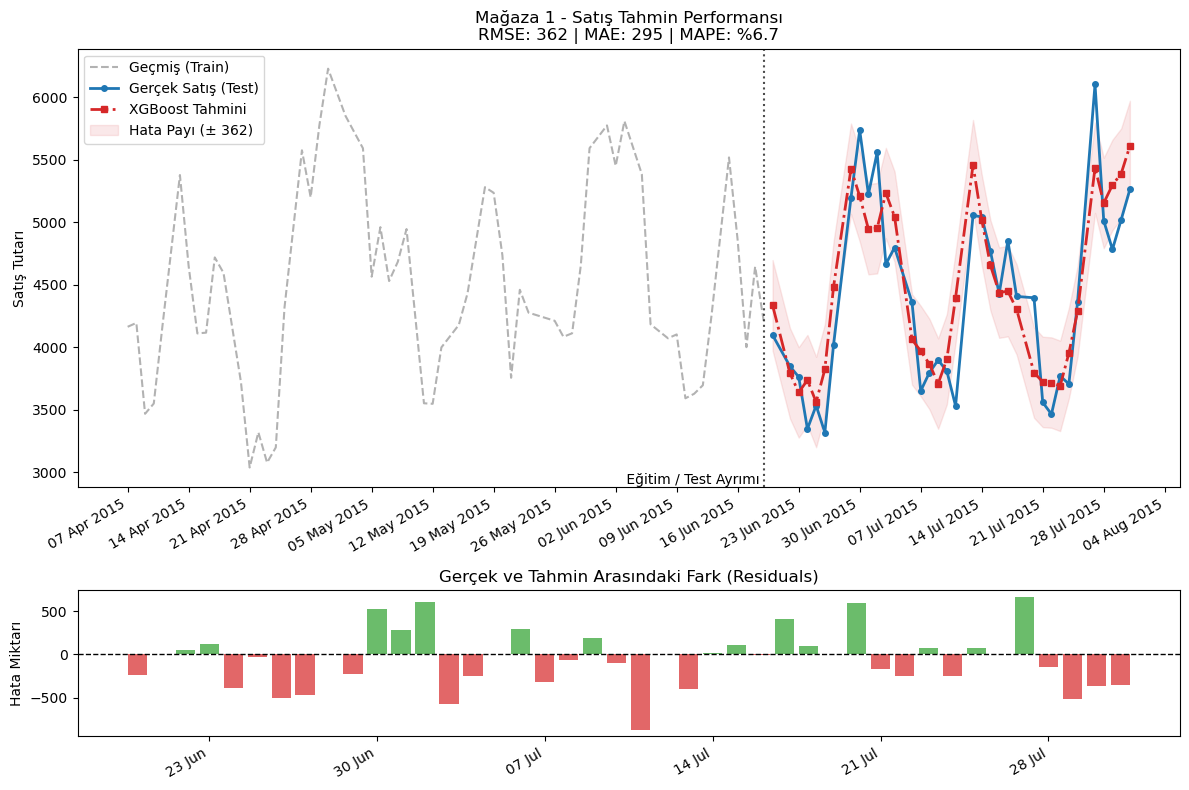

Grafik 'forecast_sonuç.png' olarak projeye kaydedildi.


In [44]:
#Grafiği Çizdiriyoruz

import matplotlib.dates as mdates

results = test[['Date', 'Sales']].copy()
results['Prediction'] = y_pred
results = results.sort_values('Date')


fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})


ax1 = axes[0]


train_tail = train.tail(60)[['Date', 'Sales']].sort_values('Date')
ax1.plot(train_tail['Date'], train_tail['Sales'],
         color='gray', linewidth=1.5, linestyle='--',
         label='Geçmiş (Train)', alpha=0.6)

ax1.plot(results['Date'], results['Sales'],
         color='tab:blue', linewidth=2, marker='o', markersize=4,
         label='Gerçek Satış (Test)')

ax1.plot(results['Date'], results['Prediction'],
         color='tab:red', linewidth=2, linestyle='-.', marker='s', markersize=4,
         label='XGBoost Tahmini')


ax1.fill_between(results['Date'],
                 results['Prediction'] - rmse,
                 results['Prediction'] + rmse,
                 color='tab:red', alpha=0.1,
                 label=f'Hata Payı (± {rmse:.0f})')


ax1.axvline(x=cutoff_date, color='black', linestyle=':', linewidth=1.5, alpha=0.7)
ax1.text(cutoff_date, ax1.get_ylim()[0], ' Eğitim / Test Ayrımı ', 
         fontsize=10, color='black', va='bottom', ha='right')

ax1.set_title(f'Mağaza {store_id} - Satış Tahmin Performansı\nRMSE: {rmse:.0f} | MAE: {mae:.0f} | MAPE: %{mape:.1f}')
ax1.set_ylabel('Satış Tutarı')
ax1.legend(loc='upper left')


ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')


ax2 = axes[1]
residuals = results['Sales'].values - results['Prediction']

# Model gerçek değerin altında kaldıysa kırmızı, üstünde kaldıysa yeşil
colors_res = ['tab:green' if r >= 0 else 'tab:red' for r in residuals]
ax2.bar(results['Date'], residuals, color=colors_res, alpha=0.7, width=0.8)
ax2.axhline(y=0, color='black', linewidth=1, linestyle='--')

ax2.set_title('Gerçek ve Tahmin Arasındaki Fark (Residuals)')
ax2.set_ylabel('Hata Miktarı')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('forecast_result.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafik 'forecast_sonuç.png' olarak projeye kaydedildi.")

In [47]:
#Önümüzdeki 1 hafta için Gelecek Tahmini yapıyoruz


last_known = store_data.tail(28)['Sales'].values


last_date = store_data['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)

future_rows = []
for i, date in enumerate(future_dates):
 
    row = {
        'DayOfWeek': date.dayofweek + 1,
        'Promo': 1,  
        'StateHoliday': 0,
        'SchoolHoliday': 0,
        
        # Mağazanın sabit bilgileri
        'StoreType': store_df[store_df['Store'] == store_id]['StoreType'].map({'a': 0, 'b': 1, 'c': 2, 'd': 3}).values[0],
        'Assortment': store_df[store_df['Store'] == store_id]['Assortment'].map({'a': 0, 'b': 1, 'c': 2}).values[0],
        'CompetitionDistance': store_df[store_df['Store'] == store_id]['CompetitionDistance'].values[0],
        
        # Zaman özellikleri
        'Year': date.year,
        'Month': date.month,
        'Day': date.day,
        'WeekOfYear': date.isocalendar().week,
        'Quarter': date.quarter,
        'IsWeekend': int(date.dayofweek >= 5),
        'IsMonthStart': int(date.is_month_start),
        'IsMonthEnd': int(date.is_month_end),
        
        # Geçmiş satış verileri 
        'Lag_7': last_known[-(7 - i)] if i < 7 else 0,
        'Lag_14': last_known[-(14 - i)] if i < 14 else 0,
        'Lag_28': last_known[-(28 - i)] if i < 28 else 0,
        
        
        'Roll_7_mean': np.mean(last_known[-7:]),
        'Roll_14_mean': np.mean(last_known[-14:]),
        'Roll_7_std': np.std(last_known[-7:])
    }
    future_rows.append(row)


future_df = pd.DataFrame(future_rows, index=future_dates)

future_preds = model.predict(future_df[features]) 


for i, date in enumerate(future_dates):
    if date.dayofweek == 6:  # 6 = Pazar
        future_preds[i] = 0


forecast_result = pd.DataFrame({
    'Tarih': future_dates.strftime('%Y-%m-%d'),
    'Gün': [date.strftime('%A') for date in future_dates],
    'Tahmini Satış': future_preds.round(0).astype(int)
})


print(f" Mağaza {store_id} : Gelecek 7 Günlük Satış Tahmini")
print(forecast_result.to_string(index=False))
print("-" * 50)
print(f"Haftalık Beklenen Toplam Satış: {future_preds.sum():,.0f} Birim")

 Mağaza 1 : Gelecek 7 Günlük Satış Tahmini
     Tarih       Gün  Tahmini Satış
2015-08-01  Saturday           5190
2015-08-02    Sunday              0
2015-08-03    Monday           5565
2015-08-04   Tuesday           5223
2015-08-05 Wednesday           4758
2015-08-06  Thursday           4800
2015-08-07    Friday           4861
--------------------------------------------------
Haftalık Beklenen Toplam Satış: 30,396 Birim
